<a href="https://colab.research.google.com/github/hanifanwibawa/datanaly/blob/18-11_Regresi/18_11_regresi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold,cross_val_score,cross_val_predict,GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import StandardScaler,OneHotEncoder

from sklearn.linear_model import LinearRegression #model regresi
from sklearn.ensemble import RandomForestRegressor ,GradientBoostingRegressor

from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error

In [ ]:
df = pd.read_csv('/content/data.csv')
df.head()

,Season,Cultivar,Repetition,PH,IFP,NLP,NGP,NGL,NS,MHG,GY
0,1,NEO 760 CE,1,58.80,15.20,98.2,177.80,1.81,5.2,152.20,3232.82
1,1,NEO 760 CE,2,58.60,13.40,102.0,195.00,1.85,7.2,141.69,3517.36
2,1,NEO 760 CE,3,63.40,17.20,100.4,203.00,2.02,6.8,148.81,3391.46
3,1,NEO 760 CE,4,60.27,15.27,100.2,191.93,1.89,6.4,148.50,3312.58
4,1,MANU IPRO,1,81.20,18.00,98.8,173.00,1.75,7.4,145.59,3230.99


In [ ]:
df.tail()

,Season,Cultivar,Repetition,PH,IFP,NLP,NGP,NGL,NS,MHG,GY
315,2,FTR 4288 IPRO,4,88.33,16.33,75.73,139.0,1.84,3.67,135.19,3348.931034
316,2,FTR 3190 IPRO,1,64.40,16.60,76.00,168.0,2.21,3.60,145.69,3418.850575
317,2,FTR 3190 IPRO,2,64.60,17.60,116.80,271.2,2.32,3.80,147.24,3651.586207
318,2,FTR 3190 IPRO,3,58.80,14.80,86.40,180.6,2.09,2.20,156.32,3487.931034
319,2,FTR 3190 IPRO,4,62.60,16.33,93.07,206.6,2.21,3.20,157.61,3605.310345


In [ ]:
print(df.shape)

(320, 11)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 320 entries, 0 to 319
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Season      320 non-null    int64  
 1   Cultivar    320 non-null    object 
 2   Repetition  320 non-null    int64  
 3   PH          320 non-null    float64
 4   IFP         320 non-null    float64
 5   NLP         320 non-null    float64
 6   NGP         320 non-null    float64
 7   NGL         320 non-null    float64
 8   NS          320 non-null    float64
 9   MHG         320 non-null    float64
 10  GY          320 non-null    float64
dtypes: float64(8), int64(2), object(1)
memory usage: 27.6+ KB


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
target = 'GY'

X = df.drop(target,axis=1)
y = df[target]

In [ ]:
X.head()

,Season,Cultivar,Repetition,PH,IFP,NLP,NGP,NGL,NS,MHG
0,1,NEO 760 CE,1,58.80,15.20,98.2,177.80,1.81,5.2,152.20
1,1,NEO 760 CE,2,58.60,13.40,102.0,195.00,1.85,7.2,141.69
2,1,NEO 760 CE,3,63.40,17.20,100.4,203.00,2.02,6.8,148.81
3,1,NEO 760 CE,4,60.27,15.27,100.2,191.93,1.89,6.4,148.50
4,1,MANU IPRO,1,81.20,18.00,98.8,173.00,1.75,7.4,145.59


In [ ]:
X['Season'].unique()

array([1, 2])

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42) #tanpa stratify

# X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=X['Season']) #stratify season

In [ ]:
print (f"X_train : {X_train.shape}")
print (f"X_test : {X_test.shape}")
print (f"y_train : {y_train.shape}")
print (f"y_test : {y_test.shape}")

X_train : (256, 10)
X_test : (64, 10)
y_train : (256,)
y_test : (64,)


In [ ]:
train_df = X_train.copy()
train_df[target] =  y_train.values

In [ ]:
train_df.head()

,Season,Cultivar,Repetition,PH,IFP,NLP,NGP,NGL,NS,MHG,GY
132,1,SYN2282IPRO,1,56.2,13.2,43.6,98.2,2.25,2.8,183.46,2888.050000
317,2,FTR 3190 IPRO,2,64.6,17.6,116.8,271.2,2.32,3.8,147.24,3651.586207
234,2,TMG 22X83I2X,3,55.4,9.0,82.0,114.4,1.40,3.2,182.95,3348.270115
312,2,FTR 4288 IPRO,1,82.6,16.0,84.0,147.2,1.75,3.6,146.98,3475.448276
232,2,TMG 22X83I2X,1,65.2,12.8,75.2,105.0,2.48,4.0,184.11,3300.275862


In [ ]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 256 entries, 132 to 102
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Season      256 non-null    int64  
 1   Cultivar    256 non-null    object 
 2   Repetition  256 non-null    int64  
 3   PH          256 non-null    float64
 4   IFP         256 non-null    float64
 5   NLP         256 non-null    float64
 6   NGP         256 non-null    float64
 7   NGL         256 non-null    float64
 8   NS          256 non-null    float64
 9   MHG         256 non-null    float64
 10  GY          256 non-null    float64
dtypes: float64(8), int64(2), object(1)
memory usage: 24.0+ KB


In [ ]:
cat_cols = ["Season","Cultivar"]
num_cols = [c for c in X_train.columns if c not in cat_cols]

print(f"numerical colom : {num_cols}")
print(f"categorical colom : {cat_cols}")

numerical colom : ['Repetition', 'PH', 'IFP', 'NLP', 'NGP', 'NGL', 'NS', 'MHG']
categorical colom : ['Season', 'Cultivar']


In [ ]:
display(train_df[num_cols + [target]].describe())

,Repetition,PH,IFP,NLP,NGP,NGL,NS,MHG,GY
count,256.000000,256.000000,256.000000,256.000000,256.000000,256.000000,256.00000,256.000000,256.000000
mean,2.527344,68.075117,15.396289,59.539023,136.934336,2.313281,4.04250,168.159297,3420.990881
std,1.133809,8.945074,3.047777,20.578641,63.061567,0.916899,1.43622,19.707243,501.497193
min,1.000000,47.600000,7.200000,20.200000,51.400000,0.940000,0.80000,127.760000,1538.230000
25%,1.750000,62.420000,13.600000,44.350000,96.150000,2.020000,3.00000,153.570000,3113.526982
50%,3.000000,67.200000,15.530000,54.500000,122.800000,2.280000,3.80000,165.635000,3424.785287
75%,4.000000,74.017500,17.200000,71.220000,166.250000,2.480000,4.88500,183.182500,3720.541667
max,4.000000,94.800000,26.400000,123.000000,683.400000,14.860000,9.00000,216.000000,4759.200000


In [ ]:
season_data = train_df["Season"].value_counts()
display(season_data)

,count
Season,
1,128
2,128


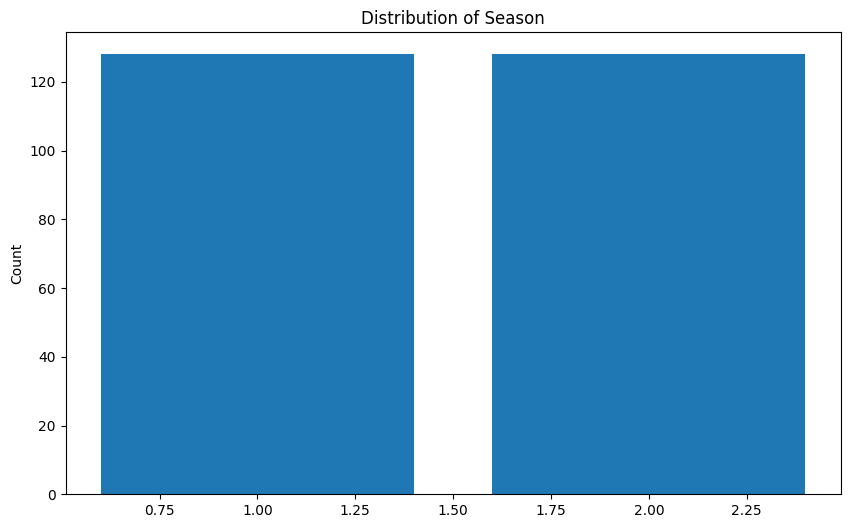

In [ ]:
plt.figure(figsize=(10, 6))
plt.bar(season_data.index, season_data.values)
plt.ylabel("Count")
plt.title("Distribution of Season")
plt.show()

In [ ]:
cultivar_data = train_df["Cultivar"].value_counts()
display(cultivar_data)

,count
Cultivar,
SYN2282IPRO,8
FTR 4288 IPRO,8
MONSOY M8606I2X,8
97Y97 IPRO,8
FTR 3868 IPRO,7
LAT 1330BT,7
FTR 3190 IPRO,7
ELISA IPRO,7
ATAQUE I2X,7


In [ ]:
corr = train_df[num_cols + [target]].corr()

display(corr[target].sort_values(ascending=False))

,GY
GY,1.000000
NGP,0.249071
NLP,0.213330
NS,0.171931
IFP,0.113137
PH,0.111553
MHG,0.084278
NGL,0.075805
Repetition,0.002253


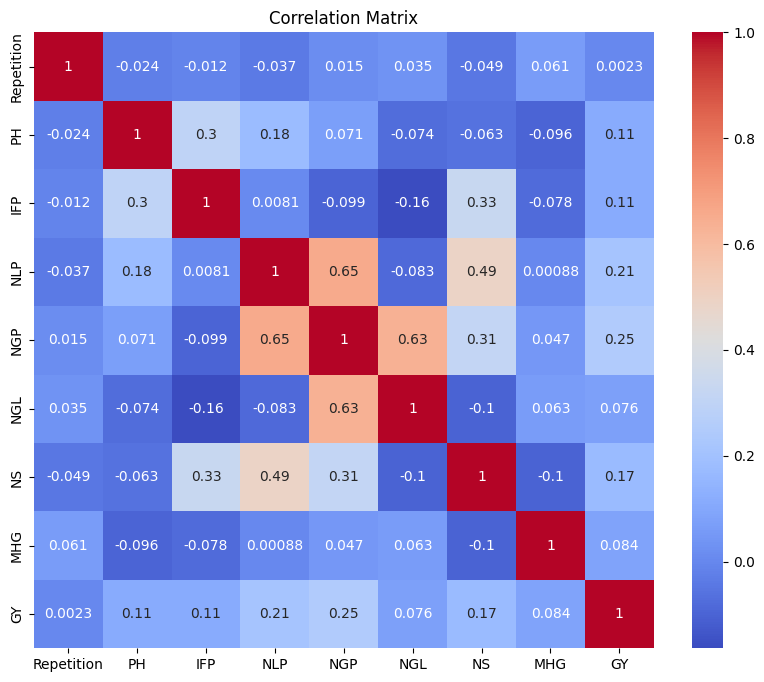

In [ ]:
# confusion matrix correlation

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

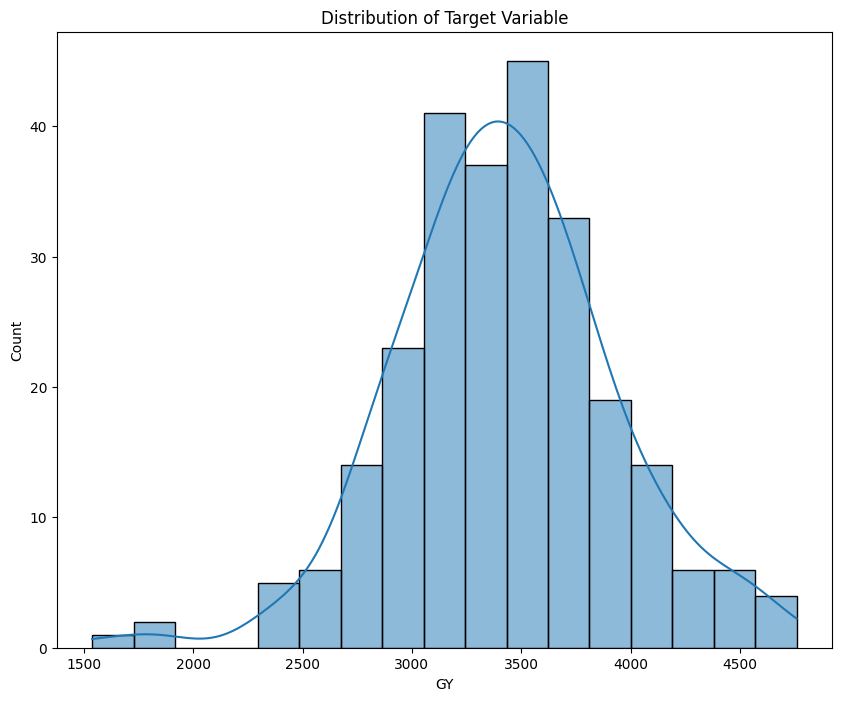

In [ ]:
plt.figure(figsize=(10, 8))
sns.histplot(train_df[target], kde=True)
plt.title('Distribution of Target Variable')
plt.show()

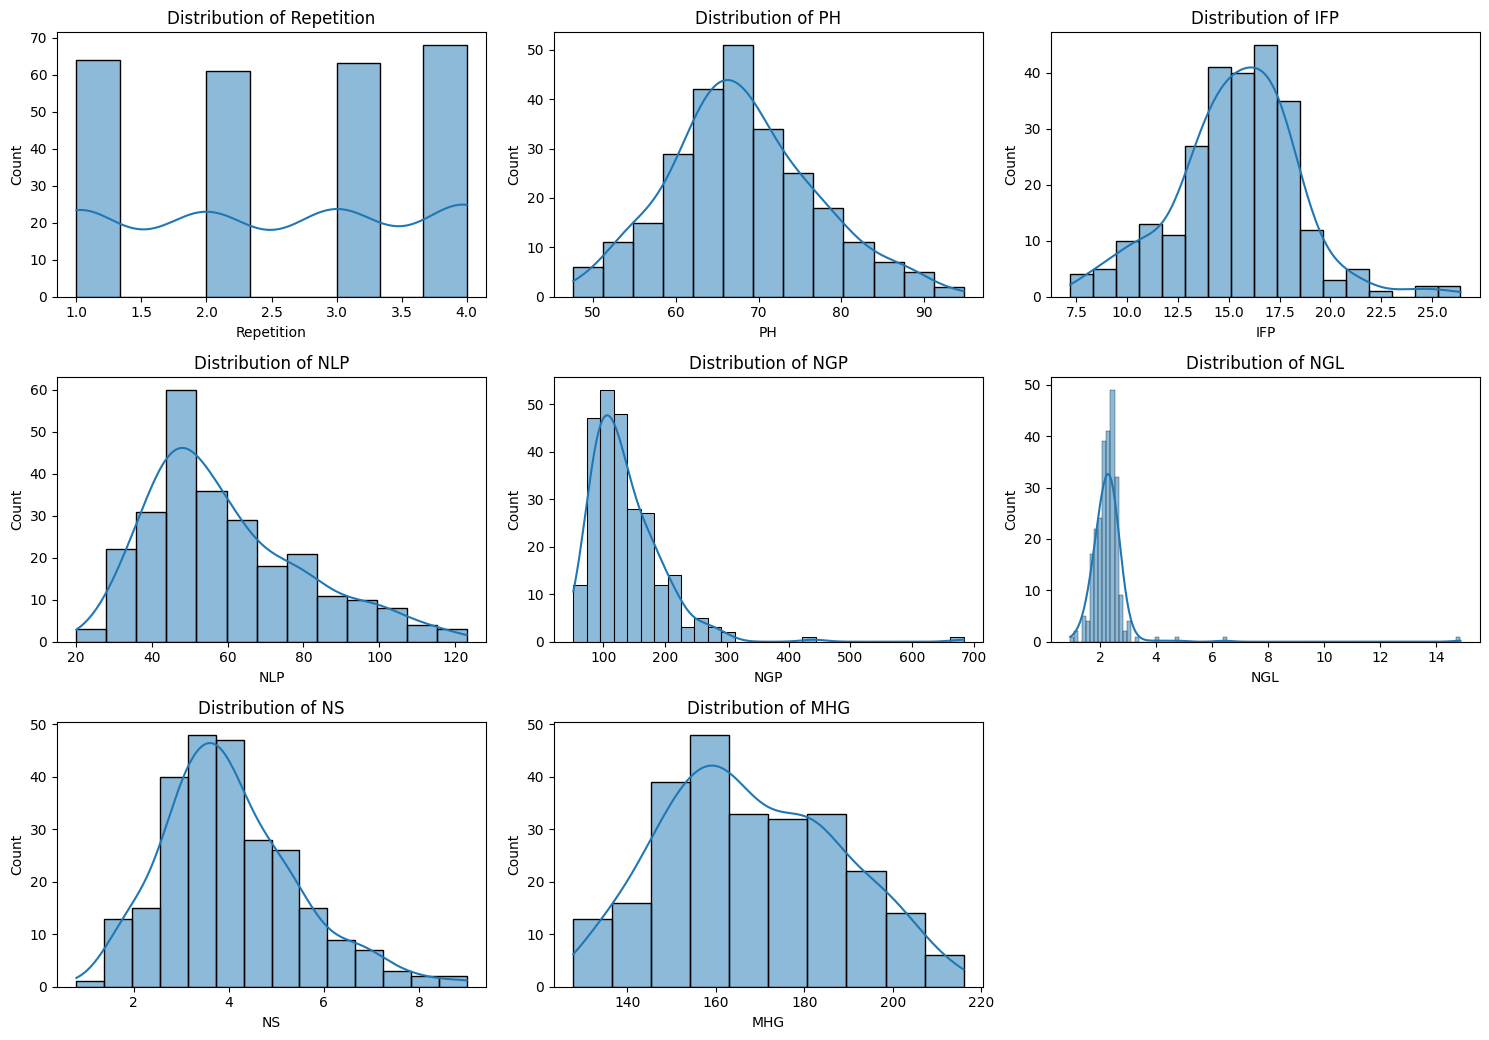

In [ ]:
n_cols_plot = 3
n_rows_plot = int(np.ceil(len(num_cols) / n_cols_plot))

plt.figure(figsize=(5*n_rows_plot, 3.5* n_cols_plot))

for i,col in enumerate (num_cols):
  plt.subplot(n_rows_plot, n_cols_plot, i+1)
  sns.histplot(train_df[col], kde=True)
  plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()


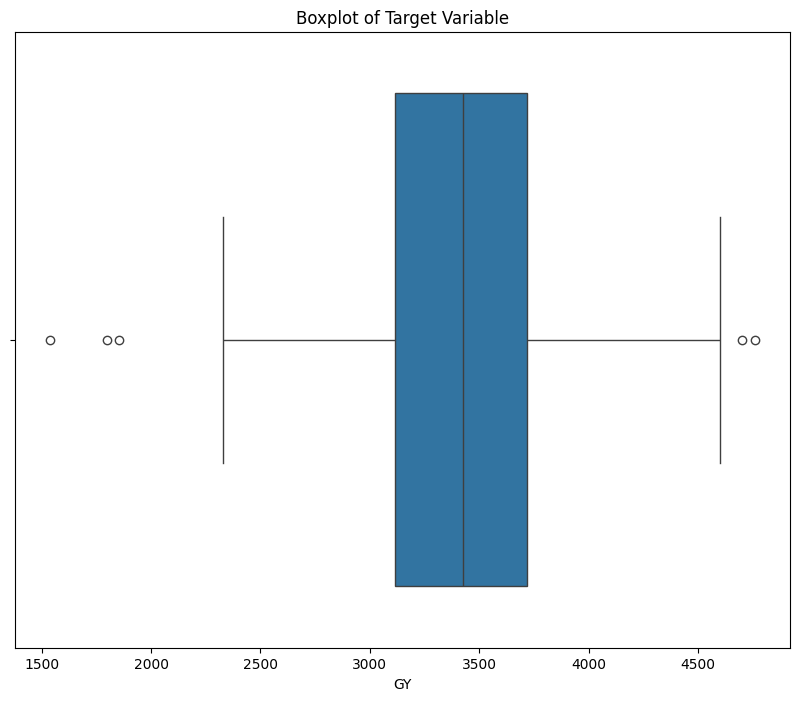

In [ ]:
plt.figure(figsize=(10, 8))
sns.boxplot(x=train_df[target])
plt.title('Boxplot of Target Variable')
plt.show()

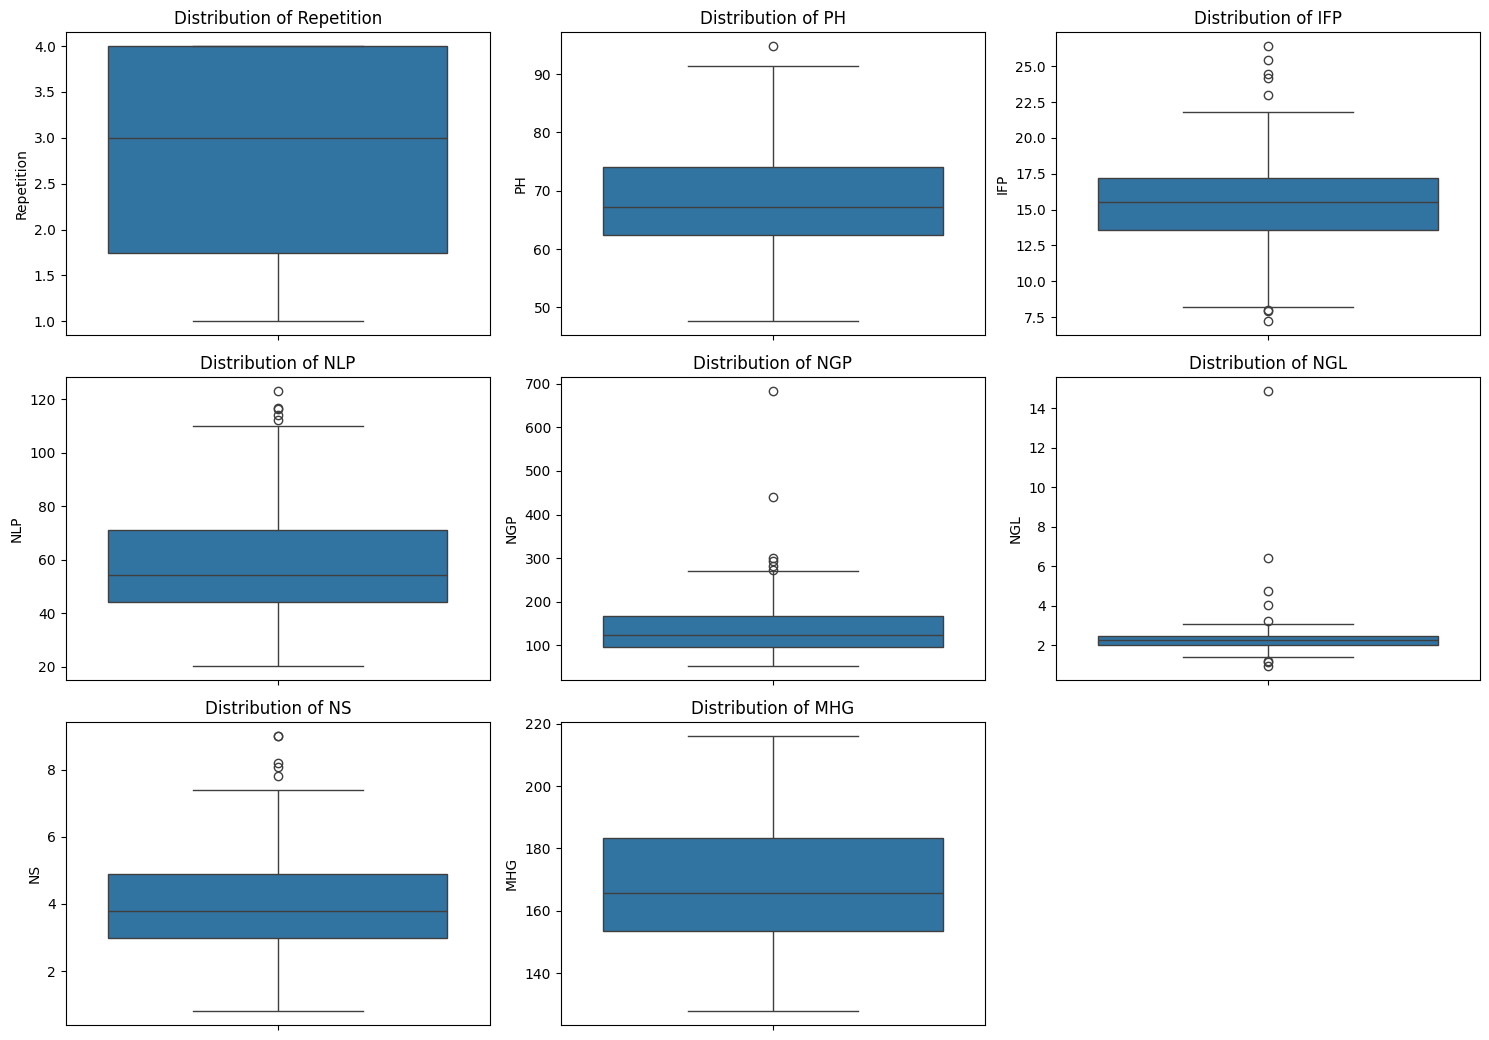

In [ ]:
plt.figure(figsize=(5*n_rows_plot, 3.5* n_cols_plot))
for i,col in enumerate (num_cols):
  plt.subplot(n_rows_plot, n_cols_plot, i+1)
  sns.boxplot(train_df[col])
  plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

In [ ]:
numeric_transform = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transform = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transform, num_cols),
        ('cat', categorical_transform, cat_cols)
    ])

In [ ]:
preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('scaler', StandardScaler())]),
                                 ['Repetition', 'PH', 'IFP', 'NLP', 'NGP',
                                  'NGL', 'NS', 'MHG']),
                                ('cat',
                                 Pipeline(steps=[('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['Season', 'Cultivar'])])

In [ ]:
kf = KFold(n_splits=3, shuffle=True, random_state=42)

def evaluate_oof (pipeline,X,y,kf,name="model"):
  oof_preds = cross_val_predict(
      pipeline,
      X,
      y,
      cv=kf,
  )

  mae = mean_absolute_error(y,oof_preds)
  mse = mean_squared_error(y,oof_preds)
  rmse = np.sqrt(mse)
  r2 = r2_score(y,oof_preds)

  print(f"MAE : {mae}")
  print(f"MSE : {mse}")
  print(f"RMSE : {rmse}")
  print(f"R2 : {r2}")

  return {
      "model" : name,
      "mae" : mae,
      "mse" : mse,
      "rmse" : rmse,
      "r2" : r2,
  }

In [ ]:
pipe_linear = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

res_linear = evaluate_oof(pipe_linear,X=X_train,y=y_train,kf=kf,name="LinearRegression")

MAE : 317.9895729037543
MSE : 181272.62995714112
RMSE : 425.7612358554277
R2 : 0.27640591582272456


In [ ]:
pipe_gbr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', GradientBoostingRegressor())
])

gbr_linear = evaluate_oof(pipe_gbr,X=X_train,y=y_train,kf=kf,name="GradientBoostingRegressor")

MAE : 289.74328328317125
MSE : 147418.50475064156
RMSE : 383.95117495671445
R2 : 0.4115429452254076


In [ ]:
pipe_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor())
])

rf_linear = evaluate_oof(pipe_rf,X=X_train,y=y_train,kf=kf,name="RandomForestRegressor")


MAE : 303.0917179254297
MSE : 158776.0331800036
RMSE : 398.46710426333016
R2 : 0.36620658979047704


In [ ]:
pipe_gbr_tuning = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', GradientBoostingRegressor())
])

param_grid = {
    'model__n_estimators': [50, 100,200,500],
    'model__learning_rate': [0.01, 0.1, 0.2],
    'model__max_depth': [3, 4, 5]
}

grid_search = GridSearchCV(pipe_gbr_tuning, param_grid, cv=3, scoring='neg_mean_squared_error')
grid_search.fit(X_train, y_train)

best_params = grid_search.best_params_

print("best CV Score (MAE)",grid_search.best_score_)
print("Best Parameters:", best_params )

best CV Score (MAE) -130820.80185756081
Best Parameters: {'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 500}


In [ ]:
best_pipe = grid_search.best_estimator_

# Latih ulang di full train
best_pipe.fit(X_train, y_train)

# Evaluasi di test (sekali saja)
y_test_pred = best_pipe.predict(X_test)

mae_test = mean_absolute_error(y_test, y_test_pred)
mse_test = mean_squared_error(y_test, y_test_pred)
rmse_test = np.sqrt(mse_test)
r2_test = r2_score(y_test, y_test_pred)

print("=== METRIK DI TEST SET (final) ===")
print(f"MAE  : {mae_test:.4f}")
print(f"RMSE : {rmse_test:.4f}")
print(f"MSE  : {mse_test:.4f}")
print(f"R2   : {r2_test:.4f}")

=== METRIK DI TEST SET (final) ===
MAE  : 226.0921
RMSE : 295.4601
MSE  : 87296.6627
R2   : 0.6628


In [ ]:
best_pipe

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['Repetition', 'PH', 'IFP',
                                                   'NLP', 'NGP', 'NGL', 'NS',
                                                   'MHG']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Season', 'Cultivar'])])),
                ('model', GradientBoostingRegressor(n_estimators=500))])